## Import Libraries & Load Data

In [119]:
import pandas as pd
import re
import matplotlib.pyplot as plt

Training Dataset

In [120]:
train = pd.read_csv('trainset.txt',sep='\t',names=['LABEL','HEADING','DATE','NEWS']) 
train.head()

,LABEL,HEADING,DATE,NEWS
0,1,JAPAN FIRM PLANS TO SELL U.S. FARMLAND TO JAP...,"MORIOKA, Japan, March 12 -",A Japanese real estate company said it will ...
1,-1,NORTH BH SETS ONE-FOR-FIVE OFFER FOR NORGOLD ...,"MELBOURNE, March 12 -",North Broken Hill Holdings Ltd & lt;NBHA.ME ...
2,-1,OUTOKUMPU IN COPPER DEAL WITH IBERICA DEL COBRE,"HELSINKI, June 26 -",Finland's state-owned mining company Outokum...
3,1,ROTTERDAM GRAIN HANDLER SAYS PORT BALANCE ROSE,"ROTTERDAM, April 13 -","Graan Elevator Mij, GEM, said its balance in..."
4,1,U.S. SENATE PANEL VOTES TO LIMIT COUNTY LOAN ...,(NO DATE),(NO TEXT)


## Preprocess & Clean Data

In [121]:
train.info()
print(train['LABEL'].value_counts())
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   LABEL    200 non-null    int64 
 1   HEADING  200 non-null    object
 2   DATE     200 non-null    object
 3   NEWS     200 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.4+ KB
LABEL
 1    102
-1     98
Name: count, dtype: int64


LABEL      0
HEADING    0
DATE       0
NEWS       0
dtype: int64

Combining heading and the news and lowercasing it

In [122]:
train['text'] = train['HEADING'] + " " + train['NEWS']
train['text'] = train['text'].str.lower()

print(train['text'].head())

0     japan firm plans to sell u.s. farmland to jap...
1     north bh sets one-for-five offer for norgold ...
2     outokumpu in copper deal with iberica del cob...
3     rotterdam grain handler says port balance ros...
4     u.s. senate panel votes to limit county loan ...
Name: text, dtype: object


Cleaning Data 

In [123]:
def clean(text):
    re.sub(r"http\S+", "", text),
    re.sub(r'&lt;[^>]+>', ' ', text),
    re.sub(r'[^a-z\s]', ' ', text),
    re.sub(r'\s+', ' ', text).strip()
    return text
    
train['text'] = train['text'].apply(clean)
print(train['text'].head())

0     japan firm plans to sell u.s. farmland to jap...
1     north bh sets one-for-five offer for norgold ...
2     outokumpu in copper deal with iberica del cob...
3     rotterdam grain handler says port balance ros...
4     u.s. senate panel votes to limit county loan ...
Name: text, dtype: object


## TF-IDF Vectorization

In [124]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [125]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)          
)

x_train = vectorizer.fit_transform(train['text'])
y_train = train['LABEL']

In [126]:
print("Training feature shape:", x_train.shape,y_train.shape)

Training feature shape: (200, 5000) (200,)


## Train & Classify With Logistic Regression 
* Because its Easy and Fast & Reliable

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

In [128]:
lr_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [129]:
lr_preds = lr_model.predict(x_train)
lr_acc = accuracy_score(y_train, lr_preds)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


## Classification Model Comparison

In [130]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

### Naive Bayes

In [131]:
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [132]:
nb_preds = nb_model.predict(x_train)
nb_acc = accuracy_score(y_train, nb_preds)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.995


### SVM

In [133]:
svm_model = LinearSVC()
svm_model.fit(x_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [134]:
svm_preds = svm_model.predict(x_train)
svm_acc = accuracy_score(y_train, svm_preds)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 1.0


In [135]:
print("Logistic Regression Report:\n")
print(classification_report(y_train, lr_preds))

print("Naive Bayes Report:\n")
print(classification_report(y_train, nb_preds))

print("SVM Report:\n")
print(classification_report(y_train, svm_preds))

Logistic Regression Report:

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       102

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Naive Bayes Report:

              precision    recall  f1-score   support

          -1       1.00      0.99      0.99        98
           1       0.99      1.00      1.00       102

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

SVM Report:

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        98
           1       1.00      1.00      1.00       102

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted av

In [136]:
results = pd.DataFrame({
    'Model': models,
    'Accuracy': [lr_acc, nb_acc, svm_acc],
    'F1 Score': f1_scores
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression     1.000  1.000000
1          Naive Bayes     0.995  0.995122
2                  SVM     1.000  1.000000


In [137]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_train, lr_preds)
nb_f1 = f1_score(y_train, nb_preds)
svm_f1 = f1_score(y_train, svm_preds)

models = ['Logistic Regression', 'Naive Bayes', 'SVM']
f1_scores = [lr_f1, nb_f1, svm_f1]

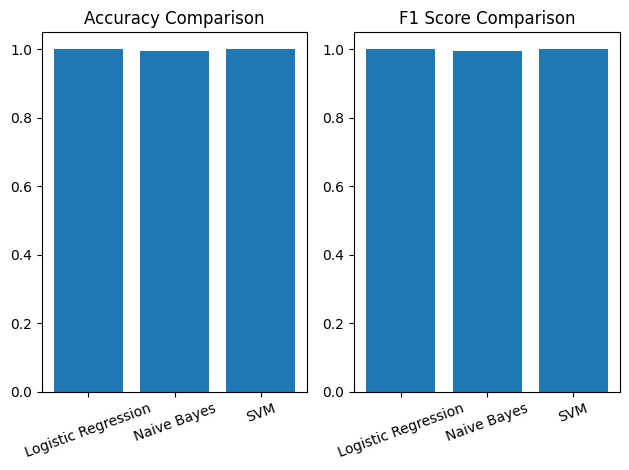

In [138]:
plt.figure()

# Accuracy plot
plt.subplot(1, 2, 1)
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.xticks(rotation=20)

# F1 Score plot
plt.subplot(1, 2, 2)
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

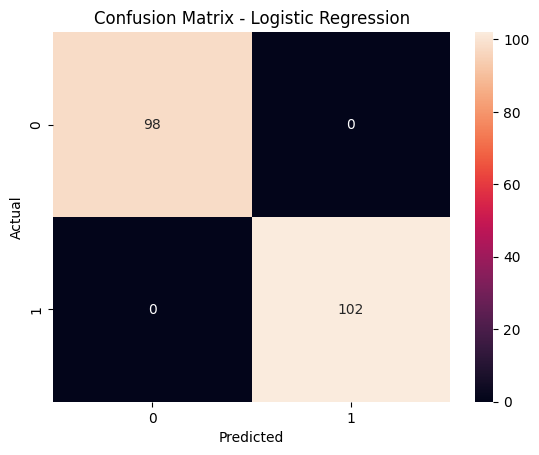

In [139]:
cm = confusion_matrix(y_train, lr_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Final Model Selection

### Load Dataset & Process

In [140]:
test = pd.read_csv("testsetwithoutlabels.txt", sep='\t',names=['HEADING','DATE','NEWS'])
test.head()

,HEADING,DATE,NEWS
0,USSR WHEAT BONUS OFFER SAID STILL UNDER DEBATE,"WASHINGTON, March 6 -",The Reagan administration continues to debat...
1,HAITIAN CANE PLANTERS PROTEST SUGAR MILL CLOSURE,"PORT-AU-PRINCE, April 13 -","About 2,000 sugar cane planters marched to P..."
2,U.S. URGES JAPAN TO OPEN FARM MARKET FURTHER,"TOKYO, April 17 -",U.S. Agriculture Secretary Richard Lyng has ...
3,NORANDA COPPER MINE SHUT DOWN AFTER FIRE,"TORONTO, April 2 -",Noranda Inc said production at its Murdochvi...
4,17 MISSING NORANDA MINERS FOUND ALIVE,"MURDOCHVILLE, Que., April 2-",Seventeen miners who were missing in a coppe...


In [141]:
test['text'] = test['HEADING'] + " " + test['NEWS']
test['text'] = test['text'].str.lower()
test['text'] = test['text'].apply(clean)

print(test['text'].head())

0     ussr wheat bonus offer said still under debat...
1     haitian cane planters protest sugar mill clos...
2     u.s. urges japan to open farm market further ...
3     noranda copper mine shut down after fire  nor...
4     17 missing noranda miners found alive  sevent...
Name: text, dtype: object


Convert to TF-IDF using the trained vectorizer

In [142]:
X_test = vectorizer.transform(test['text'])

    FINAL MODEL
* Linear Regression has the final model because it has higher Accuracy and F1 Score

In [145]:
final_model = lr_model

In [153]:
final_predictions = final_model.predict(X_test)
final_predictions = test['predicted_label']
test.to_csv("output/final_predictions.csv", index=False)

In [152]:
print(test['text'].head())
print(final_predictions.head())

0     ussr wheat bonus offer said still under debat...
1     haitian cane planters protest sugar mill clos...
2     u.s. urges japan to open farm market further ...
3     noranda copper mine shut down after fire  nor...
4     17 missing noranda miners found alive  sevent...
Name: text, dtype: object
0    1
1    1
2    1
3   -1
4   -1
Name: predicted_label, dtype: int64
